<a href="https://colab.research.google.com/github/Samplergithub769/CASE-STUDY-CUSTOMER-ANALYSIS-FOR-RETAIL/blob/main/Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
Customers=pd.read_csv("/content/Customer.csv")
Transactions=pd.read_csv("/content/Transactions.csv")
Product_Hierarchy=pd.read_csv("/content/prod_cat_info.csv")


In [38]:
Customers

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0
...,...,...,...,...
5642,274474,19-12-1992,M,2.0
5643,267666,24-12-1992,M,6.0
5644,270476,25-12-1992,F,3.0
5645,269626,27-12-1992,F,5.0


In [39]:
Transactions

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop


In [40]:
Product_Hierarchy

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women
5,2,Footwear,4,Kids
6,3,Electronics,4,Mobiles
7,3,Electronics,5,Computers
8,3,Electronics,8,Personal Appliances
9,3,Electronics,9,Cameras


 Merge the datasets Customers, Product Hierarchy and Transactions as Customer_Final. Ensure
tokeep all customers who have done transactions with us and select the join type accordingly.

In [41]:
Customer_Transaction=pd.merge(Customers,Transactions,left_on="customer_Id",right_on="cust_id",how="left")
Customer_Transaction

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,268408,02-01-1970,M,4.0,8.724384e+10,268408.0,13-01-2014,7.0,5.0,5.0,187.0,98.175,1033.175,TeleShop
1,268408,02-01-1970,M,4.0,1.619787e+10,268408.0,16-12-2013,1.0,4.0,-5.0,-210.0,110.250,-1160.250,Flagship store
2,268408,02-01-1970,M,4.0,1.619787e+10,268408.0,12-12-2013,1.0,4.0,5.0,210.0,110.250,1160.250,Flagship store
3,268408,02-01-1970,M,4.0,2.881014e+10,268408.0,02-09-2013,10.0,6.0,2.0,813.0,170.730,1796.730,TeleShop
4,268408,02-01-1970,M,4.0,6.463344e+10,268408.0,06-05-2013,4.0,2.0,3.0,312.0,98.280,1034.280,Flagship store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23189,269626,27-12-1992,F,5.0,7.136903e+10,269626.0,18-10-2011,12.0,6.0,1.0,638.0,66.990,704.990,e-Shop
23190,269626,27-12-1992,F,5.0,9.413405e+10,269626.0,07-07-2011,3.0,1.0,3.0,1078.0,339.570,3573.570,MBR
23191,274308,29-12-1992,F,5.0,2.620869e+10,274308.0,22-10-2012,1.0,2.0,2.0,898.0,188.580,1984.580,MBR
23192,274308,29-12-1992,F,5.0,5.735882e+10,274308.0,05-09-2012,1.0,2.0,4.0,876.0,367.920,3871.920,e-Shop


In [42]:
Customer_Final=pd.merge(Customer_Transaction,Product_Hierarchy,left_on=["prod_cat_code","prod_subcat_code"],right_on=["prod_cat_code","prod_sub_cat_code"],how="left")


Get the column names and their corresponding data types

In [43]:
print(Customer_Final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23194 entries, 0 to 23193
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_Id        23194 non-null  int64  
 1   DOB                23194 non-null  object 
 2   Gender             23185 non-null  object 
 3   city_code          23186 non-null  float64
 4   transaction_id     23053 non-null  float64
 5   cust_id            23053 non-null  float64
 6   tran_date          23053 non-null  object 
 7   prod_subcat_code   23053 non-null  float64
 8   prod_cat_code      23053 non-null  float64
 9   Qty                23053 non-null  float64
 10  Rate               23053 non-null  float64
 11  Tax                23053 non-null  float64
 12  total_amt          23053 non-null  float64
 13  Store_type         23053 non-null  object 
 14  prod_cat           23053 non-null  object 
 15  prod_sub_cat_code  23053 non-null  float64
 16  prod_subcat        230

Top/Bottom 10 observations

In [44]:
Customer_Final.head(10)

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,02-01-1970,M,4.0,8.724384e+10,268408.0,13-01-2014,7.0,5.0,5.0,187.0,98.175,1033.175,TeleShop,Books,7.0,Fiction
1,268408,02-01-1970,M,4.0,1.619787e+10,268408.0,16-12-2013,1.0,4.0,-5.0,-210.0,110.250,-1160.250,Flagship store,Bags,1.0,Mens
2,268408,02-01-1970,M,4.0,1.619787e+10,268408.0,12-12-2013,1.0,4.0,5.0,210.0,110.250,1160.250,Flagship store,Bags,1.0,Mens
3,268408,02-01-1970,M,4.0,2.881014e+10,268408.0,02-09-2013,10.0,6.0,2.0,813.0,170.730,1796.730,TeleShop,Home and kitchen,10.0,Kitchen
4,268408,02-01-1970,M,4.0,6.463344e+10,268408.0,06-05-2013,4.0,2.0,3.0,312.0,98.280,1034.280,Flagship store,Footwear,4.0,Kids
5,268408,02-01-1970,M,4.0,5.690286e+10,268408.0,30-01-2013,9.0,3.0,5.0,868.0,455.700,4795.700,e-Shop,Electronics,9.0,Cameras
6,268408,02-01-1970,M,4.0,5.684453e+10,268408.0,14-10-2012,1.0,2.0,5.0,1175.0,616.875,6491.875,MBR,Footwear,1.0,Mens
7,268408,02-01-1970,M,4.0,1.951606e+10,268408.0,07-09-2012,10.0,3.0,4.0,650.0,273.000,2873.000,e-Shop,Electronics,10.0,Audio and video
8,268408,02-01-1970,M,4.0,1.264450e+10,268408.0,14-08-2012,4.0,4.0,3.0,321.0,101.115,1064.115,TeleShop,Bags,4.0,Women
9,268408,02-01-1970,M,4.0,6.331455e+10,268408.0,26-04-2012,1.0,1.0,1.0,806.0,84.630,890.630,Flagship store,Clothing,1.0,Women


In [45]:
Customer_Final.tail(10)

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_sub_cat_code,prod_subcat
23184,270476,25-12-1992,F,3.0,7.803441e+10,270476.0,13-08-2013,11.0,6.0,1.0,971.0,101.955,1072.955,TeleShop,Home and kitchen,11.0,Bath
23185,270476,25-12-1992,F,3.0,3.359888e+09,270476.0,16-03-2013,10.0,3.0,4.0,361.0,151.620,1595.620,MBR,Electronics,10.0,Audio and video
23186,270476,25-12-1992,F,3.0,2.288339e+10,270476.0,22-05-2012,4.0,2.0,4.0,898.0,377.160,3969.160,Flagship store,Footwear,4.0,Kids
23187,270476,25-12-1992,F,3.0,1.972519e+10,270476.0,21-02-2012,4.0,4.0,4.0,618.0,259.560,2731.560,e-Shop,Bags,4.0,Women
23188,270476,25-12-1992,F,3.0,8.547516e+10,270476.0,09-08-2011,5.0,3.0,5.0,1354.0,710.850,7480.850,Flagship store,Electronics,5.0,Computers
23189,269626,27-12-1992,F,5.0,7.136903e+10,269626.0,18-10-2011,12.0,6.0,1.0,638.0,66.990,704.990,e-Shop,Home and kitchen,12.0,Tools
23190,269626,27-12-1992,F,5.0,9.413405e+10,269626.0,07-07-2011,3.0,1.0,3.0,1078.0,339.570,3573.570,MBR,Clothing,3.0,Kids
23191,274308,29-12-1992,F,5.0,2.620869e+10,274308.0,22-10-2012,1.0,2.0,2.0,898.0,188.580,1984.580,MBR,Footwear,1.0,Mens
23192,274308,29-12-1992,F,5.0,5.735882e+10,274308.0,05-09-2012,1.0,2.0,4.0,876.0,367.920,3871.920,e-Shop,Footwear,1.0,Mens
23193,274308,29-12-1992,F,5.0,5.816054e+10,274308.0,04-07-2012,12.0,5.0,5.0,588.0,308.700,3248.700,e-Shop,Books,12.0,Academic


4.	“Five-number summary” for continuous variables (min, Q1, median, Q3 and max)



In [46]:
cont_col=Customer_Final[['Qty','Rate','Tax','total_amt']].describe()
print(cont_col)

                Qty          Rate           Tax     total_amt
count  23053.000000  23053.000000  23053.000000  23053.000000
mean       2.432395    636.369713    248.667192   2107.308002
std        2.268406    622.363498    187.177773   2507.561264
min       -5.000000  -1499.000000      7.350000  -8270.925000
25%        1.000000    312.000000     98.280000    762.450000
50%        3.000000    710.000000    199.080000   1754.740000
75%        4.000000   1109.000000    365.715000   3569.150000
max        5.000000   1500.000000    787.500000   8287.500000


Frequency tables for all the categorical variables

In [47]:
display(Customer_Final['Gender'].value_counts())

,count
Gender,
M,11877
F,11308


In [48]:
display(Customer_Final['Store_type'].value_counts())

,count
Store_type,
e-Shop,9311
MBR,4661
Flagship store,4577
TeleShop,4504


In [49]:
display(Customer_Final['prod_cat'].value_counts())

,count
prod_cat,
Books,6069
Electronics,4898
Home and kitchen,4129
Footwear,2999
Clothing,2960
Bags,1998


In [50]:
display(Customer_Final['prod_subcat'].value_counts())

,count
prod_subcat,
Women,3048
Mens,2912
Kids,1997
Tools,1062
Fiction,1043
Kitchen,1037
Children,1035
Mobiles,1031
Comics,1031


Generate histograms for all continuous variables and frequency bars for categorical variables.

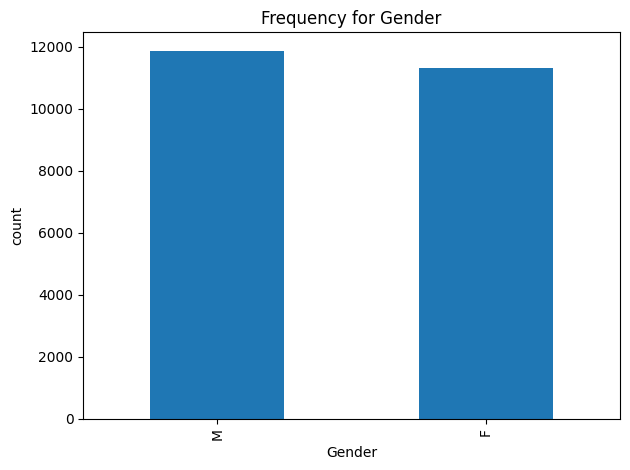

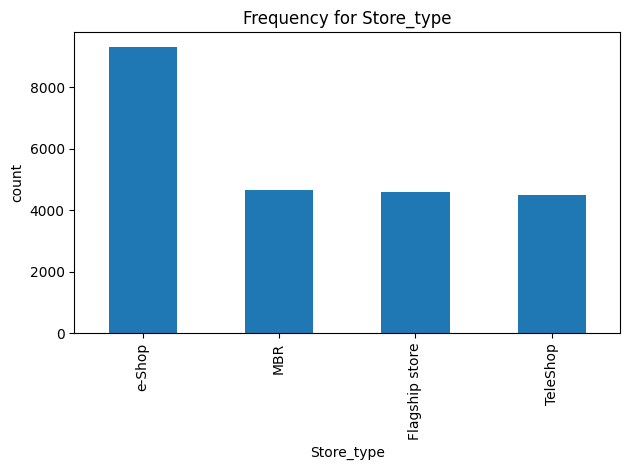

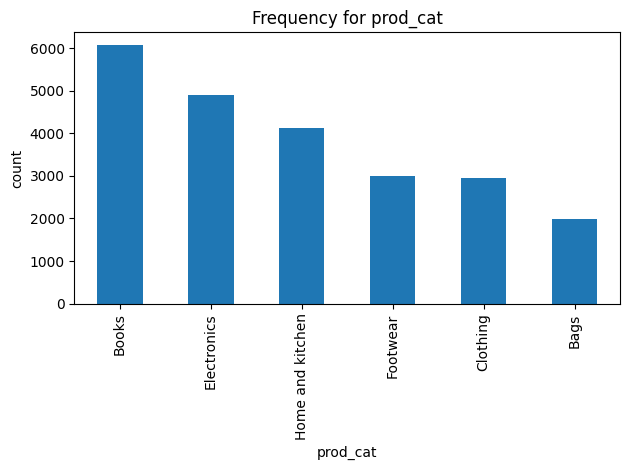

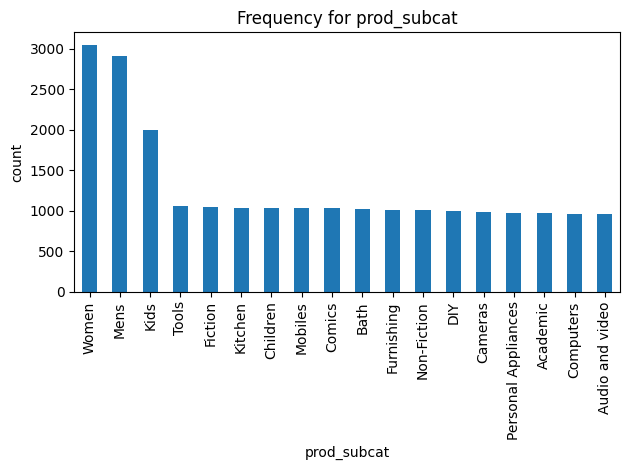

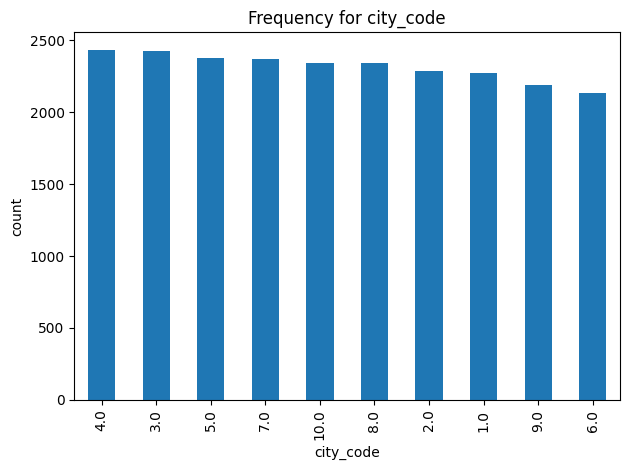

In [51]:
cols=['Gender','Store_type','prod_cat','prod_subcat','city_code']
for col in cols:
  plt.figure()
  Customer_Final[col].value_counts().plot(kind='bar')
  plt.xlabel(col)0
  plt.ylabel("count")
  plt.title(f"Frequency for {col}")
  plt.tight_layout()
  plt.show()

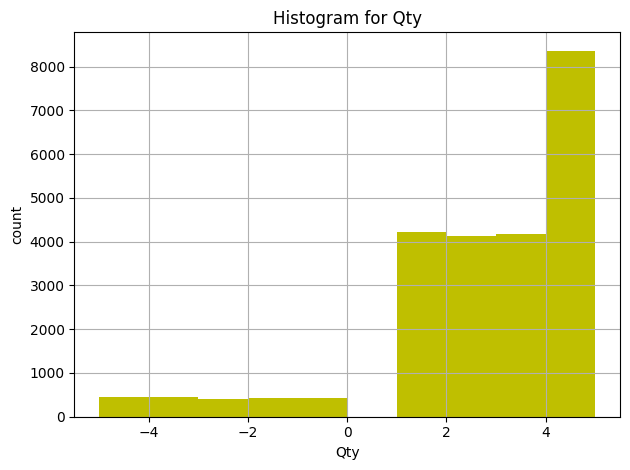

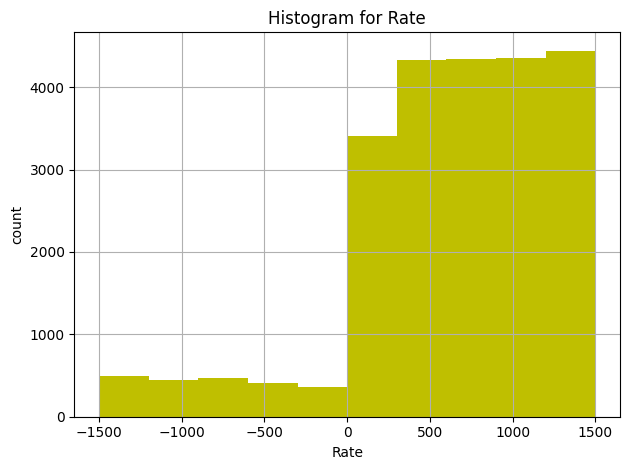

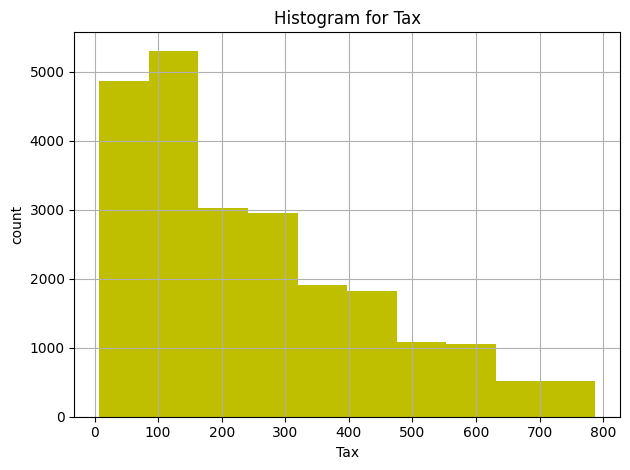

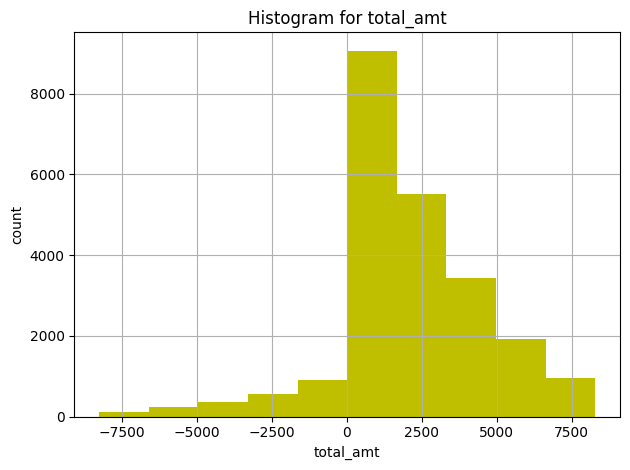

In [54]:
cont_cols=['Qty','Rate','Tax','total_amt']
for col in cont_cols:
  plt.figure()
  Customer_Final[col].hist(color='y')
  plt.xlabel(col)
  plt.ylabel("count")
  plt.title(f"Histogram for {col}")
  plt.tight_layout()
  plt.show()


Time period of the available transaction data